# 06. 3차 모델링 : XGBOOST

# 작업 순서

1. Train/Test 분포 비교
2. Train / Validation / Test 분할
3. XGBoost 모델 학습
4. 피처 중요도 확인
5. 성능 비교: MLR vs LightGBM vs XGBoost
6. XGBoost 예측값 저장

# 사용 피처셋

(LightGBM과 동일)

# 0. 데이터 업로드

활용 데이터셋: dataset_final_ML1조.csv

In [7]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.stats import ks_2samp

import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

from google.colab import files
print("▶ dataset_final_ML1조 파일 업로드")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)


▶ dataset_final_ML1조 파일 업로드


Saving dataset_final_ML1조.csv to dataset_final_ML1조.csv


In [ ]:

!sudo apt-get install -y fonts-nanum

import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("등록된 폰트 확인:", [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name])

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (30.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and direc

## 1. Train/Test 분포 비교 (Distribution Shift 확인)

`data_split` 기준 Train(2023 ~ 2024)과 Test(2025 ~ 2026) 사이에 `면적당가격_만원` 분포가 시간에 따라 얼마나 달라졌는지 확인.


=== 연도별 면적당가격_만원 기술통계 ===
      count   mean    std    min    25%    50%     75%     max
계약연도                                                          
2023  332.0  814.9  348.6  138.7  569.3  790.0  1016.5  1631.8
2024  362.0  791.2  347.4  108.3  505.8  767.7  1004.0  2094.8
2025  374.0  767.8  344.0  131.6  545.7  717.4   979.6  1579.0
2026  218.0  863.9  339.3  140.6  600.3  869.9  1114.8  1607.9

=== KS 검정 (Train vs Test) ===
KS statistic = 0.0358, p-value = 0.7879
→ Train/Test 분포 차이가 통계적으로 유의미하지 않음


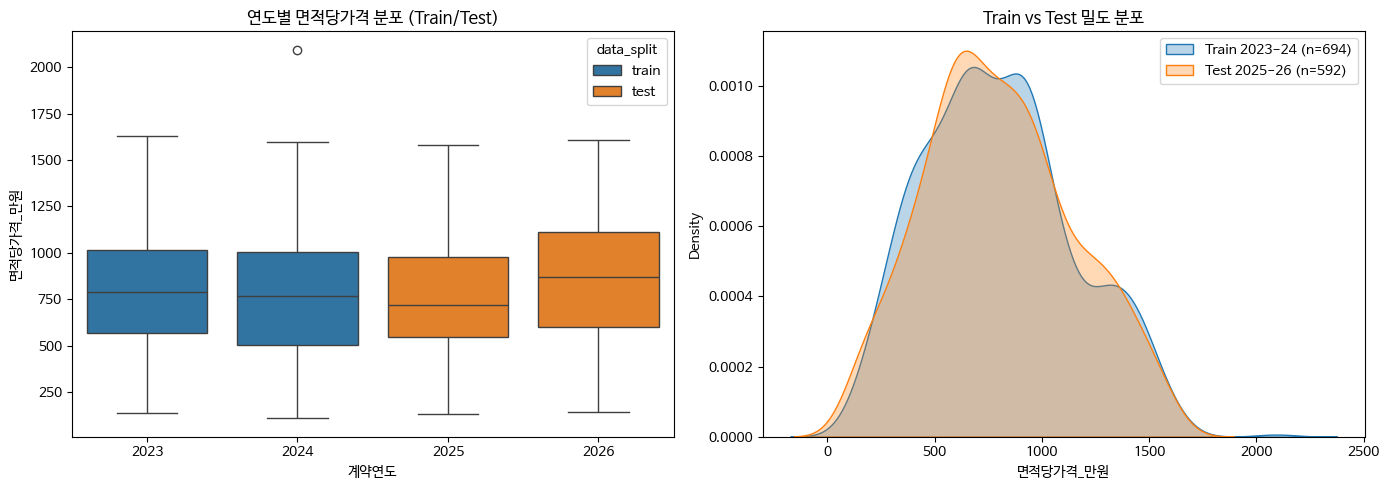

In [ ]:
print("=== 연도별 면적당가격_만원 기술통계 ===")
print(df.groupby('계약연도')['면적당가격_만원'].describe().round(1))

train_prices = df.loc[df['data_split'] == 'train', '면적당가격_만원']
test_prices = df.loc[df['data_split'] == 'test', '면적당가격_만원']

stat, pval = ks_2samp(train_prices, test_prices)
print(f"\n=== KS 검정 (Train vs Test) ===")
print(f"KS statistic = {stat:.4f}, p-value = {pval:.4g}")
if pval < 0.05:
    print("→ Train/Test 분포 차이가 통계적으로 유의미함 (distribution shift 존재)")
else:
    print("→ Train/Test 분포 차이가 통계적으로 유의미하지 않음")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='계약연도', y='면적당가격_만원', hue='data_split',
            dodge=False, ax=axes[0])
axes[0].set_title('연도별 면적당가격 분포 (Train/Test)')
axes[0].legend(title='data_split')

sns.kdeplot(train_prices, label=f'Train 2023-24 (n={len(train_prices)})', ax=axes[1], fill=True, alpha=0.3)
sns.kdeplot(test_prices, label=f'Test 2025-26 (n={len(test_prices)})', ax=axes[1], fill=True, alpha=0.3)
axes[1].set_title('Train vs Test 밀도 분포')
axes[1].set_xlabel('면적당가격_만원')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Train / Validation / Test 분할 (시간순)

`data_split` 컬럼(계약연도 기준)으로 Train(2023 ~ 2024) / Test(2025 ~ 2026)를 나누되,

XGBoost의 early stopping용 validation은 **test를 쓰지 않고 train 내부를 시간순으로 한 번 더 쪼갬.**

- 학습(train): 계약연도 2023
- 검증(validation, early stopping 전용): 계약연도 2024
- 최종 평가(test): 2025~2026 — **여기서는 최종 성능 측정 1회에만 사용, 모델 학습/튜닝에는 절대 관여하지 않음**


In [ ]:
train_test_split_raw = df[df['data_split'] == 'train'].copy()
test_df = df[df['data_split'] == 'test'].copy()

train_df = train_test_split_raw[train_test_split_raw['계약연도'] == 2023].copy()
val_df = train_test_split_raw[train_test_split_raw['계약연도'] == 2024].copy()

print(f"Train(2023): {train_df.shape[0]}건")
print(f"Val(2024)  : {val_df.shape[0]}건")
print(f"Test(2025~2026): {test_df.shape[0]}건")
print(f"\n(참고) 06번 기준 원래 train 전체: {train_test_split_raw.shape[0]}건 (2023+2024)")


Train(2023): 332건
Val(2024)  : 362건
Test(2025~2026): 592건

(참고) 06번 기준 원래 train 전체: 694건 (2023+2024)


In [ ]:
target = '면적당가격_만원'
features_gbm = [
    'log_전용면적', '층', '주택연령', 'is_basement',
    'SK미래관거리', '보문역거리',
    '면적라벨_소형', '면적라벨_중형',
    '전월세구분_전세', '동그룹_안암동', '주택유형_연립'
]

X_train = train_df[features_gbm]
y_train = train_df[target]
X_val = val_df[features_gbm]
y_val = val_df[target]
X_test = test_df[features_gbm]
y_test = test_df[target]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


X_train: (332, 11), X_val: (362, 11), X_test: (592, 11)


## 3. XGBoost 모델 학습 (Validation 기반 Early Stopping)

LightGBM 설정(`num_leaves=15`, `min_child_samples=10`, `n_estimators=500`, `learning_rate=0.05`)에 대응해
XGBoost 파라미터를 다음과 같이 매핑함.

| LightGBM | XGBoost | 의도 |
|---|---|---|
| num_leaves=15 | max_depth=4 (2^4=16 리프) | 표본 332건(train 2023) 규모에 맞춘 과적합 방지 |
| min_child_samples=10 | min_child_weight=5 | 리프당 최소 표본 규제 |
| n_estimators=500, learning_rate=0.05 | 동일 | 동일 |
| early_stopping(50 rounds), eval on val | early_stopping_rounds=50, eval on **validation(2024)** | test는 최종 평가 전용으로 분리 |


In [ ]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse',
    importance_type='gain',
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration}")

# 최종 평가는 test(2025~2026)에서 단 한 번만 수행
y_pred = xgb_model.predict(X_test, iteration_range=(0, xgb_model.best_iteration + 1))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print(" [XGBoost] Test 데이터(25~26년) 예측 성능")
print("=" * 60)
print(f"▶ Test R-squared (설명력): {r2:.4f}")
print(f"▶ Test RMSE (평균 오차액): {rmse:.1f} 만원/m²")
print(f"▶ Test MAE  (절대 오차액): {mae:.1f} 만원/m²")
print(f"▶ Best iteration: {xgb_model.best_iteration}")
print("=" * 60)


Best iteration: 236
 [XGBoost] Test 데이터(25~26년) 예측 성능
▶ Test R-squared (설명력): 0.7984
▶ Test RMSE (평균 오차액): 154.9 만원/m²
▶ Test MAE  (절대 오차액): 117.7 만원/m²
▶ Best iteration: 236


# 4. 피처 중요도 확인

 🔍 XGBoost Feature Importance (gain 기준)
    Feature  Importance
    면적라벨_중형    0.216170
    면적라벨_소형    0.170352
   log_전용면적    0.167236
       주택연령    0.120304
    SK미래관거리    0.107482
      보문역거리    0.084714
   전월세구분_전세    0.060956
    동그룹_안암동    0.045256
          층    0.018377
    주택유형_연립    0.009153
is_basement    0.000000


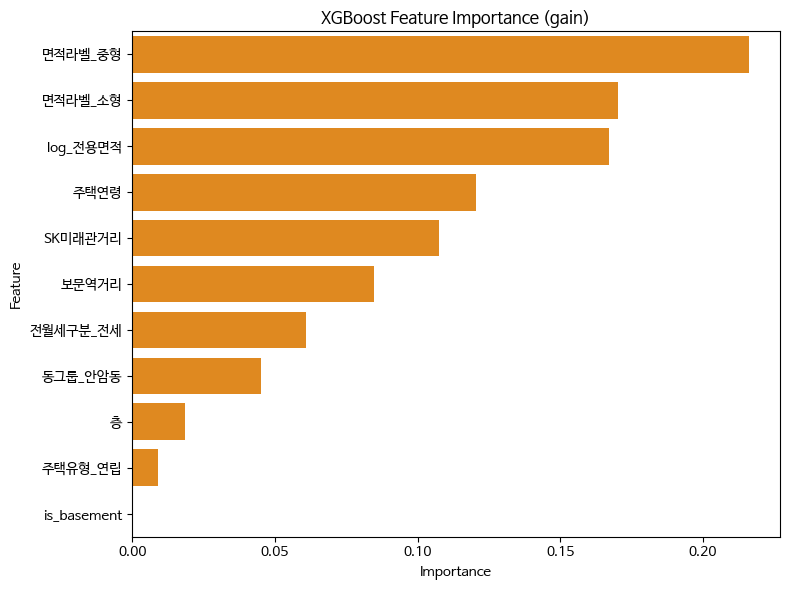

In [ ]:
importance_df = pd.DataFrame({
    'Feature': features_gbm,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 60)
print(" 🔍 XGBoost Feature Importance (gain 기준)")
print("=" * 60)
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='darkorange')
plt.title('XGBoost Feature Importance (gain)')
plt.tight_layout()
plt.show()


## 5. 성능 비교: MLR vs LightGBM vs XGBoost



In [8]:
results_summary = pd.DataFrame({
    'Model': ['MLR2', 'LightGBM', 'XGBoost'],
    'Test_R2': [0.649, 0.805, r2],
    'Test_RMSE': [204.2, 152.2, rmse],
    'Test_MAE': [159.3, 110.2, mae],
})

results_summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,MLR2,0.649000,204.200000,159.300000
1,LightGBM,0.805000,152.200000,110.200000
2,XGBoost,0.798391,154.851063,117.654737


## 6. XGBoost 예측값 저장


In [10]:
predictions_df = pd.DataFrame({
    'data_split': test_df['data_split'].values,
    'row_id': test_df.index,
    'actual': y_test.values,
    'xgb_pred': y_pred,
})

predictions_df.to_csv('xgboost_predictions.csv', index=False)

from google.colab import files
files.download('xgboost_predictions.csv')

predictions_df.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,data_split,row_id,actual,xgb_pred
0,test,694,734.693878,818.522095
1,test,695,1385.615671,1310.367676
2,test,696,1182.658444,1145.966187
3,test,697,426.621160,416.908966
4,test,698,984.638597,722.979187
